<a href="https://colab.research.google.com/github/cpsinghrajput9110-sudo/desktop-tutorial/blob/main/PSO_and_QPSOAlgorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**#PSO Algorithm**

In [5]:
import random
import numpy as np
def fun(x):
  return 418.9829 - x * np.sin(np.sqrt(np.abs(x)))

num_particle=10

particle_X = [np.random.randint(300,500) for _ in range(num_particle)]
particle_V=[0]*num_particle

pBestValue=[fun(x) for x in particle_X]
pBestCoor=particle_X

gBestValue=min(pBestValue)
gBestCoor=particle_X[np.argmin(pBestValue)]



minValue=[]
minX=[]

#Hyper parameter
w=0.5
c1=3
c2=2

num_iteration=100
for itr in range(num_iteration):
  print("iteration",itr)
  for i in range(num_particle):
    r1=random.uniform(0,1)
    r2=random.uniform(0,1)
    if(fun(particle_X[i]<pBestValue[i])):
      pBestValue[i]=fun(particle_X[i])
      pBestCoor[i]=particle_X[i]
    if min(pBestValue)<gBestValue:
      gBestValue=min(pBestValue)
      gBestCoor=particle_X[np.argmin(pBestValue)]
    particle_V[i]=w*particle_V[i] + c1*r1*(pBestCoor[i]-particle_X[i]) + c2*r2*(gBestCoor-particle_X[i])
    particle_X[i]+=particle_V[i]
  minValue.append(gBestValue)
  minX.append(gBestCoor)
  print("particle_X",particle_X)
  print("particle_V",particle_V)
  print("pBestValue",pBestValue)
  print("pBestCoor",pBestCoor)
  print("gBestValue",gBestValue)
  print("gBestCoor",gBestCoor)




iteration 0
particle_X [313.1809846794427, 463.3629582062268, 404.0179399988921, 426.6869874950473, 412.80205499261314, 470.1108457639508, 463.19703794730816, 354.18016228530377, 425.0, 483.2042910896]
particle_V [9.180984679442725, -27.637041793773232, -61.98206000110794, -5.313012504952709, 73.80205499261314, 122.11084576395079, 152.19703794730816, 6.180162285303787, 0.0, 143.20429108960005]
pBestValue [np.float64(719.2517243248606), np.float64(500.7790283841783), np.float64(235.74909221475494), np.float64(15.327042518660164), np.float64(562.6408653215525), np.float64(486.3446260256179), np.float64(710.4358054354419), np.float64(486.3446260256179), np.float64(2.052130724699225), np.float64(554.6556793428122)]
pBestCoor [313.1809846794427, 463.3629582062268, 404.0179399988921, 426.6869874950473, 412.80205499261314, 470.1108457639508, 463.19703794730816, 354.18016228530377, 425.0, 483.2042910896]
gBestValue 2.052130724699225
gBestCoor 425
iteration 1
particle_X [429.633010218931, 435.2

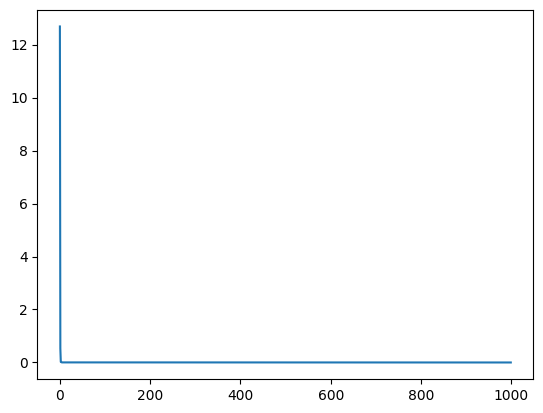

In [ ]:
import matplotlib.pyplot as plt
plt.plot(minValue)
plt.show()

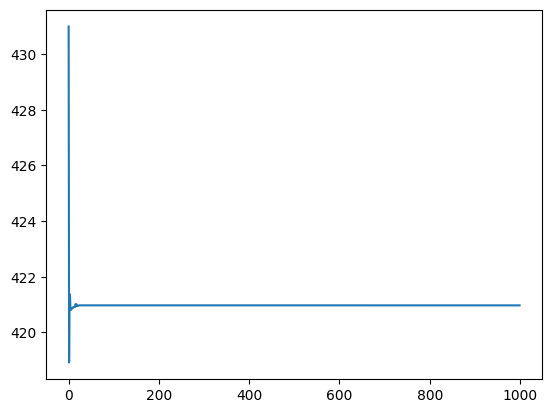

In [ ]:
import matplotlib.pyplot as plt
plt.plot(minX)
plt.show()

**#QPSO Algorithm**

In [6]:
import random
import numpy as np



# Schwefel function: minimum is near x = 420.9687
def fun(x):
    return 418.9829 - x * np.sin(np.sqrt(abs(x)))


# Hyperparameters
num_particles = 30



# Create random particle positions
particle_x = [np.random.randint(300,500) for _ in range(num_particles)]

# Personal best
pbest_coor = particle_x.copy()
pbest_value = ([fun(x) for x in particle_x])

# Global best
best_index = np.argmin(pbest_value)
gbest_coor = pbest_coor[best_index]
gbest_value = pbest_value[best_index]

min_value = []
min_x = []

# QPSO beta controls exploration and exploitation
beta_max = 1.0
beta_min = 0.5

num_iterations = 100
for itr in range(num_iterations):

    # Beta gradually decreases: exploration -> exploitation
    beta = beta_max - (beta_max - beta_min) * (itr / num_iterations)

    # mbest = mean value of all personal best positions
    mbest = np.mean(pbest_coor)

    for i in range(num_particles):

        # Random values required for QPSO
        phi = random.uniform(0, 1)
        u = random.uniform(0.0001, 1)

        # Local attractor: combines pbest and gbest
        attractor = phi * pbest_coor[i] + (1 - phi) * gbest_coor

        # Random direction: plus or minus
        direction = random.choice([-1, 1])

        # QPSO position update equation
        particle_x[i] = (
            attractor
            + direction
            * beta
            * abs(mbest - particle_x[i])
            * np.log(1 / u)
        )

        # Keep particle inside allowed search range
        particle_x[i] = np.clip(
            particle_x[i],
            200,
            500
        )

        # Update personal best
        current_value = fun(particle_x[i])

        if current_value < pbest_value[i]:
            pbest_value[i] = current_value
            pbest_coor[i] = particle_x[i]

    # Update global best after all particles move
    best_index = np.argmin(pbest_value)

    if pbest_value[best_index] < gbest_value:
        gbest_value = pbest_value[best_index]
        gbest_coor = pbest_coor[best_index]

    min_value.append(gbest_value)
    min_x.append(gbest_coor)

    print(
        f"Iteration {itr + 1}: "
        f"Best X = {gbest_coor:.4f}, "
        f"Best Value = {gbest_value:.6f}"
    )


print("\nFinal QPSO Result")
print("Best X:", gbest_coor)
print("Minimum Value:", gbest_value)




Iteration 1: Best X = 422.0000, Best Value = 0.134253
Iteration 2: Best X = 421.5998, Best Value = 0.050279
Iteration 3: Best X = 421.4616, Best Value = 0.030664
Iteration 4: Best X = 421.3007, Best Value = 0.013915
Iteration 5: Best X = 421.1185, Best Value = 0.002842
Iteration 6: Best X = 421.0730, Best Value = 0.001384
Iteration 7: Best X = 421.0730, Best Value = 0.001384
Iteration 8: Best X = 421.0730, Best Value = 0.001384
Iteration 9: Best X = 421.0730, Best Value = 0.001384
Iteration 10: Best X = 421.0730, Best Value = 0.001384
Iteration 11: Best X = 420.9381, Best Value = 0.000132
Iteration 12: Best X = 420.9381, Best Value = 0.000132
Iteration 13: Best X = 420.9381, Best Value = 0.000132
Iteration 14: Best X = 420.9827, Best Value = 0.000037
Iteration 15: Best X = 420.9685, Best Value = 0.000013
Iteration 16: Best X = 420.9685, Best Value = 0.000013
Iteration 17: Best X = 420.9685, Best Value = 0.000013
Iteration 18: Best X = 420.9685, Best Value = 0.000013
Iteration 19: Best 

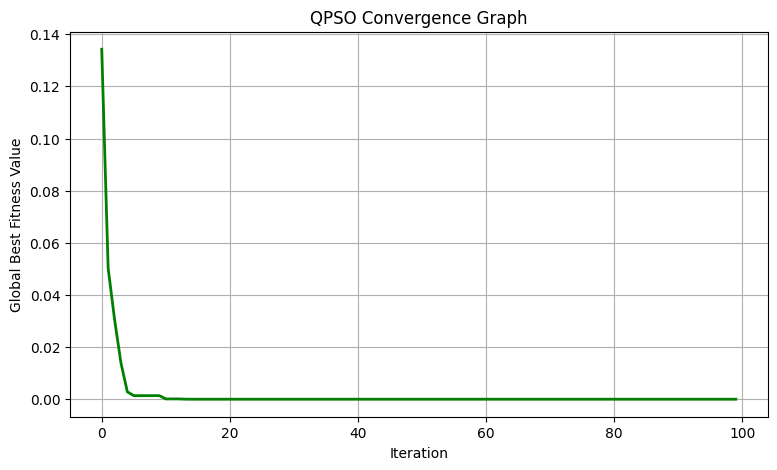

In [7]:
# Convergence graph
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(min_value, color="green", linewidth=2)
plt.title("QPSO Convergence Graph")
plt.xlabel("Iteration")
plt.ylabel("Global Best Fitness Value")
plt.grid(True)
plt.show()